In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
import numpy as np
import os
import random
import cv2
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [2]:
class CustomRegressionTarget:
    def __init__(self, category):
        self.category = category
    def __call__(self, model_output):
        if len(model_output.shape) == 1:
            return model_output[self.category]
        return model_output[:, self.category]

In [3]:
class PilotNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 24, 5, stride=2), nn.ReLU(),
            nn.Conv2d(24, 36, 5, stride=2), nn.ReLU(),
            nn.Conv2d(36, 48, 5, stride=2), nn.ReLU(),
            nn.Conv2d(48, 64, 3), nn.ReLU(),
            nn.Conv2d(64, 64, 3), nn.ReLU(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 66, 200)
            n_features = self.conv(dummy).view(1, -1).size(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_features, 100), nn.ReLU(),
            nn.Linear(100, 50), nn.ReLU(),
            nn.Linear(50, 10), nn.ReLU(),
            nn.Linear(10, 2)
        )
    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = PilotNet().to(device)
model.load_state_dict(torch.load("../carla_tests/weigths/w_157_st_65_35_045.pth", map_location=device))
model.eval()

PilotNet(
  (conv): Sequential(
    (0): Conv2d(3, 24, kernel_size=(5, 5), stride=(2, 2))
    (1): ReLU()
    (2): Conv2d(24, 36, kernel_size=(5, 5), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(36, 48, kernel_size=(5, 5), stride=(2, 2))
    (5): ReLU()
    (6): Conv2d(48, 64, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (9): ReLU()
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=100, bias=True)
    (2): ReLU()
    (3): Linear(in_features=100, out_features=50, bias=True)
    (4): ReLU()
    (5): Linear(in_features=50, out_features=10, bias=True)
    (6): ReLU()
    (7): Linear(in_features=10, out_features=2, bias=True)
  )
)

In [5]:
preprocess = T.Compose([
    T.Resize((66, 200)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

target_layers = [model.conv[-2]]
cam = GradCAM(model=model, target_layers=target_layers)

In [6]:
df_path = "/home/jrguezg/2025-tfg-jorge-rodriguez/common_utils/datasets/TOWN01_30K_ST"
images_list = [f for f in os.listdir(df_path) if f.endswith(".png")]
random_images = random.sample(images_list, 3)

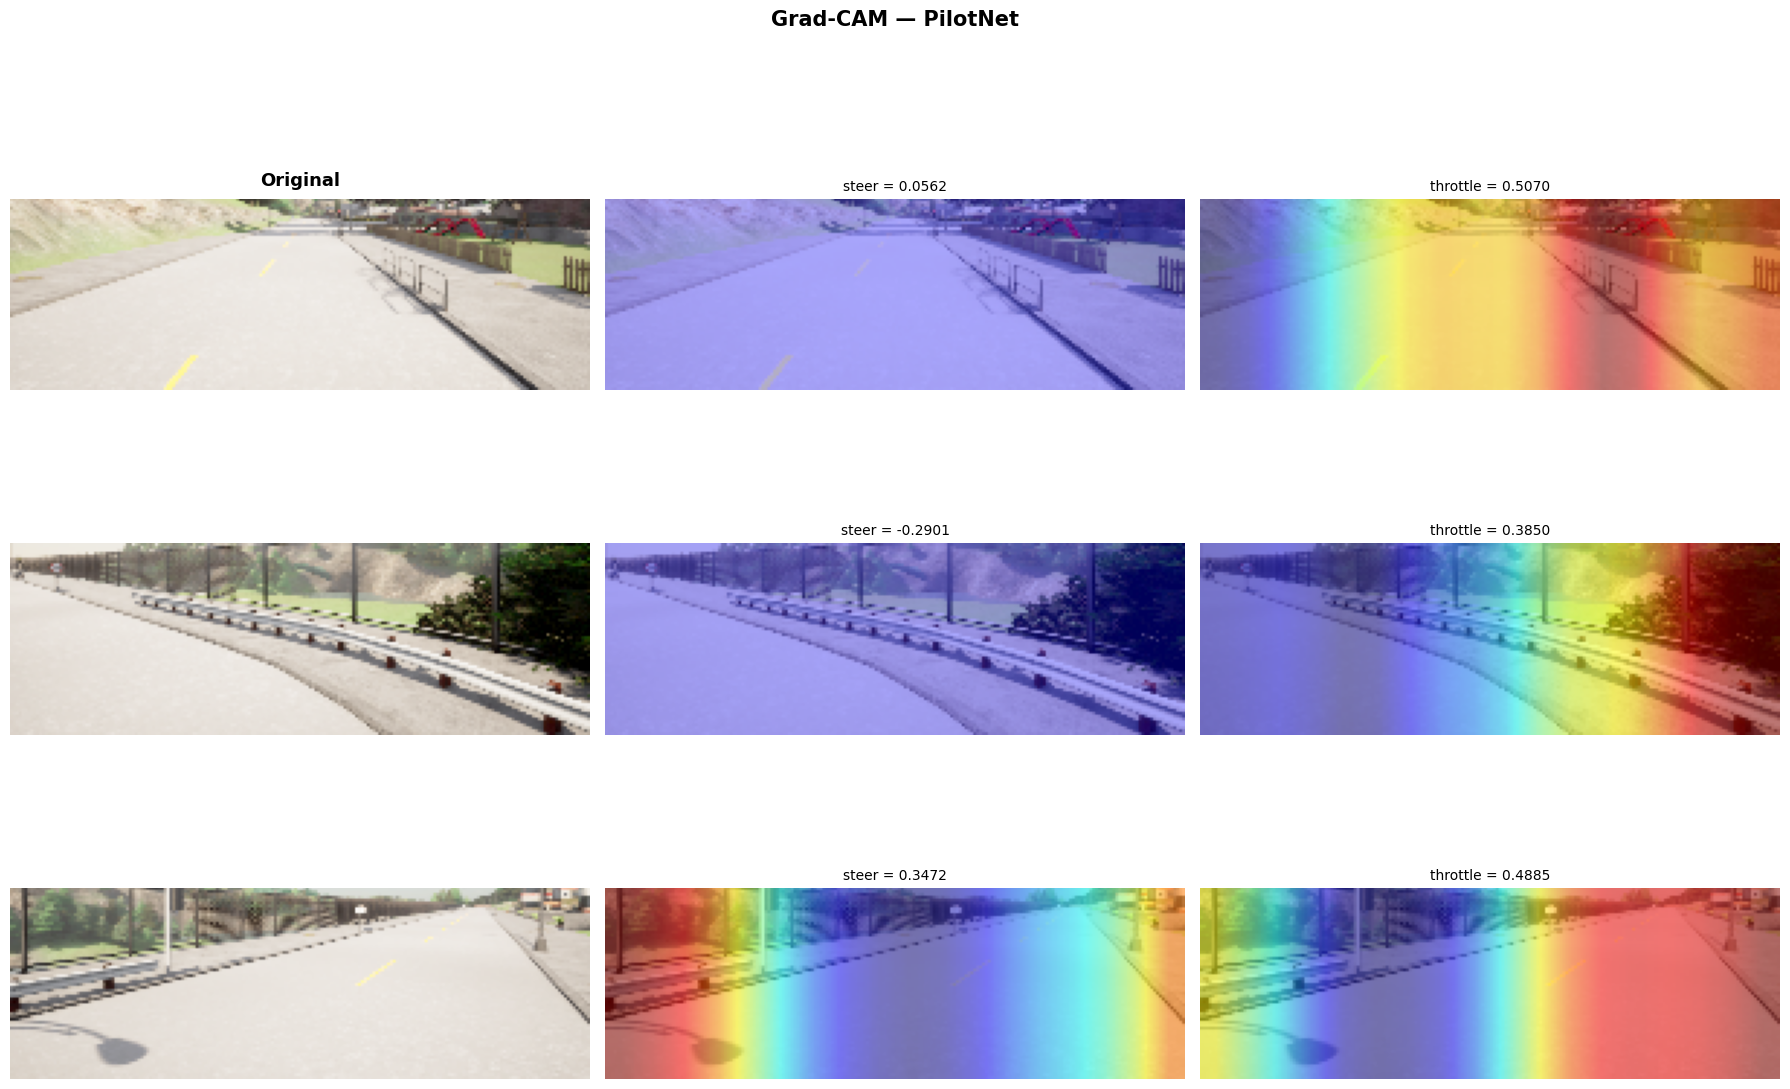

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
col_titles = ["Original", "Grad-CAM Steering", "Grad-CAM Throttle"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)

for row, img_name in enumerate(random_images):
    full_path = os.path.join(df_path, img_name)

    raw_img = cv2.cvtColor(cv2.imread(full_path), cv2.COLOR_BGR2RGB)
    h, w = raw_img.shape[:2]
    img_cropped = raw_img[int(h * 0.45):, :]
    img_resized = cv2.resize(img_cropped, (200, 66))
    img_float = img_resized.astype(np.float32) / 255.0

    img_pil = Image.fromarray(img_cropped)
    input_tensor = preprocess(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        preds = model(input_tensor)
    p_steer = preds[0, 0].item()
    p_throt = preds[0, 1].item()

    grayscale_steer = cam(input_tensor=input_tensor, targets=[CustomRegressionTarget(0)])[0]
    vis_steer = show_cam_on_image(img_float, grayscale_steer, use_rgb=True)

    grayscale_throt = cam(input_tensor=input_tensor, targets=[CustomRegressionTarget(1)])[0]
    vis_throt = show_cam_on_image(img_float, grayscale_throt, use_rgb=True)

    axes[row, 0].imshow(img_resized)
    axes[row, 0].set_ylabel(f"Frame {row+1}", fontsize=11, fontweight="bold")
    axes[row, 1].imshow(vis_steer)
    axes[row, 1].set_title(f"steer = {p_steer:.4f}", fontsize=10)
    axes[row, 2].imshow(vis_throt)
    axes[row, 2].set_title(f"throttle = {p_throt:.4f}", fontsize=10)

    for ax in axes[row]:
        ax.axis("off")

plt.suptitle("Grad-CAM — PilotNet", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("gradcam_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
layer_options = {
    "conv[0] - 24@31x98":  model.conv[0],
    "conv[2] - 36@14x47":  model.conv[2],
    "conv[4] - 48@5x22":   model.conv[4],
    "conv[6] - 64@3x20":   model.conv[6],
    "conv[8] - 64@1x18":   model.conv[8],
}

img_name = random.choice(images_list)
full_path = os.path.join(df_path, img_name)

raw_img     = cv2.cvtColor(cv2.imread(full_path), cv2.COLOR_BGR2RGB)
h, w        = raw_img.shape[:2]
img_cropped = raw_img[int(h * 0.45):, :]
img_resized = cv2.resize(img_cropped, (200, 66))
img_float   = img_resized.astype(np.float32) / 255.0
img_pil     = Image.fromarray(img_cropped)
input_tensor = preprocess(img_pil).unsqueeze(0).to(device)

fig, axes = plt.subplots(2, 5, figsize=(22, 6))
fig.suptitle("Comparativa capas Grad-CAM — Steering", fontsize=13, fontweight="bold")

for col, (name, layer) in enumerate(layer_options.items()):
    cam_test = GradCAM(model=model, target_layers=[layer])
    grayscale = cam_test(input_tensor=input_tensor,
                         targets=[CustomRegressionTarget(0)])[0]
    vis = show_cam_on_image(img_float, grayscale, use_rgb=True)

    axes[0, col].imshow(img_resized)
    axes[0, col].set_title(name, fontsize=8)
    axes[0, col].axis("off")

    axes[1, col].imshow(vis)
    axes[1, col].axis("off")

plt.tight_layout()
plt.savefig("gradcam_layer_comparison.png", dpi=150, bbox_inches="tight")
plt.show()